# Step 1: Environment Setup and Data Loading

## 1.1 Import Libraries


In [ ]:
!pip install imbalanced-learn

In [ ]:
!pip install tabulate

In [ ]:
!pip install tensorflow imbalanced-learn

In [ ]:
from google.colab import drive
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import tensorflow as tf
import sklearn.utils as utils

In [ ]:
# Scikit-Learn
# Preprocessing and feature engineering
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, FunctionTransformer
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.combine import SMOTETomek

# Model algorithm
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluation indicators
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve
)

# Imbalanced-Learn
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# TensorFlow
from tensorflow import keras
from keras import layers, models, callbacks

## 1.2 Load Data


In [ ]:
drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/TC6444/TC6444_Project/healthcare-dataset-stroke-data.csv'

df = pd.read_csv(file_path)
print(df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
      id  gender   age  hypertension  heart_disease ever_married  \
0   9046    Male  67.0             0              1          Yes   
1  51676  Female  61.0             0              0          Yes   
2  31112    Male  80.0             0              1          Yes   
3  60182  Female  49.0             0              0          Yes   
4   1665  Female  79.0             1              0          Yes   

       work_type Residence_type  avg_glucose_level   bmi   smoking_status  \
0        Private          Urban             228.69  36.6  formerly smoked   
1  Self-employed          Rural             202.21   NaN     never smoked   
2        Private          Rural             105.92  32.5     never smoked   
3        Private          Urban             171.23  34.4           smokes   
4  Self-employed          Rural             174.12  24.0     never smoked   


##1.3 Data Splitting

In [ ]:
X = df.drop('stroke', axis=1)
y = df['stroke']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Step 2: Data Preprocessing

##2.1 Missing Value

In [ ]:
def suggest_imputation_strategy(df, threshold=1.0, show_plot=True):

    # Filter out numeric columns with missing values
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    missing_cols = [col for col in numeric_cols if df[col].isnull().sum() > 0]

    strategies = {}

    if not missing_cols:
        print("No numeric columns with missing values found.")
        return strategies

    print(f"======== Missing Value & Skewness Analysis (Threshold={threshold}) ========")

    for col in missing_cols:
        # Calculate missing counts and percentages for each column
        missing_count = df[col].isnull().sum()
        missing_pct = (missing_count / len(df)) * 100

        # Compute skewness (ignore NaN)
        skewness = df[col].skew()

        # Decision logic
        is_skewed = abs(skewness) > threshold
        strategy = 'median' if is_skewed else 'mean'
        strategies[col] = strategy

        # Print analysis report
        print(f"\nTarget Column: '{col}'")
        print(f" -> Missing: {missing_count} ({missing_pct:.2f}%)")
        print(f" -> Skewness: {skewness:.4f}")

        if is_skewed:
            print(f" -> Conclusion: Distribution is SEVERELY SKEWED (abs > {threshold}).")
            print(f" -> Recommendation: Use MEDIAN imputation.")
        else:
            print(f" -> Conclusion: Distribution is relatively normal.")
            print(f" -> Recommendation: Use MEAN imputation.")

        # Visualization
        if show_plot:
            plt.figure(figsize=(8, 4))
            sns.histplot(df[col].dropna(), kde=True, color='skyblue', edgecolor='black')

            # Draw the positions of Mean and Median
            col_mean = df[col].mean()
            col_median = df[col].median()

            plt.axvline(col_mean, color='red', linestyle='--', label=f'Mean: {col_mean:.2f}')
            plt.axvline(col_median, color='green', linestyle='-', linewidth=2, label=f'Median: {col_median:.2f}')

            plt.title(f"Distribution of '{col}' (Skewness: {skewness:.2f})")
            plt.legend()
            plt.show()

    return strategies


======== Missing Value & Skewness Analysis (Threshold=1.0) ========

Target Column: 'bmi'
 -> Missing: 201 (3.93%)
 -> Skewness: 1.0551
 -> Conclusion: Distribution is SEVERELY SKEWED (abs > 1.0).
 -> Recommendation: Use MEDIAN imputation.


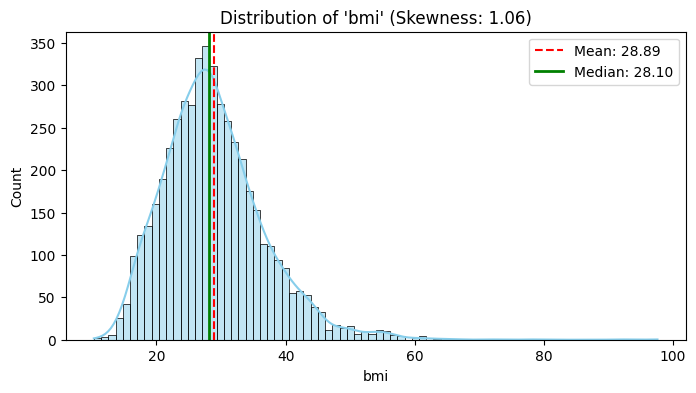

{'bmi': 'median'}


In [ ]:
imputation_strategy = suggest_imputation_strategy(df, threshold=1.0)
print(imputation_strategy)

##2.2 Detect data imbalance

In [ ]:
def detect_imbalance(df, target_col, extreme_threshold=10):

    print(f"========  Imbalance Detect Report: '{target_col}' ========")

    # 1. Basic statistics
    counts = df[target_col].value_counts()
    percentages = df[target_col].value_counts(normalize=True) * 100

    majority_class = counts.idxmax()
    minority_class = counts.idxmin()

    majority_count = counts.max()
    minority_count = counts.min()

    ratio = majority_count / minority_count

    # 2. Print detailed evidence (for report)
    print(f"Class Distribution (Counts):\n{counts.to_string()}")
    print(f"\nClass Percentage:\n{percentages.to_string(float_format='%.2f%%')}")
    print(f"\nImbalance Ratio: 1 : {ratio:.2f}")

    # 3. Automatic diagnosis and recommendation
    print("\n>>>  Diagnosis Results:")
    if ratio < 1.5:
        print("Data is relatively balanced. No special handling required.")
        recommendation = "None"
    elif ratio < extreme_threshold:
        print(f"Moderate imbalance (Ratio < {extreme_threshold}).")
        print("Recommendation: Use `class_weight='balanced'` parameter during training, or mild resampling.")
        recommendation = "Class Weights / Mild Resampling"
    else:
        print(f"Extreme imbalance (Ratio > {extreme_threshold})!")
        print("Recommendation: Must use SMOTE (oversampling) or Undersampling, otherwise the model will be ineffective.")
        recommendation = "SMOTE"

    # 4. Generate visual evidence
    plt.figure(figsize=(8, 8))
    ax = sns.countplot(
    x=target_col,
    data=df,
    palette='viridis',
    order=counts.index,
    hue=target_col,
    legend=False
)

    plt.title(f'Class Distribution of "{target_col}"\n(Imbalance Ratio 1 : {ratio:.1f})', fontsize=14)
    plt.xlabel('Class', fontsize=12)
    plt.ylabel('Count', fontsize=12)

    # Annotate bars with counts and percentages
    for i, p in enumerate(ax.patches):
        height = p.get_height()
        ax.text(p.get_x() + p.get_width()/2., height + (height*0.02),
                f'{height}\n({percentages[counts.index[i]]:.1f}%)',
                ha="center", fontsize=11, fontweight='bold')

    plt.show()

    return ratio, recommendation

========  Imbalance Detect Report: 'stroke' ========
Class Distribution (Counts):
stroke
0    4860
1     249

Class Percentage:
stroke
0   95.13%
1    4.87%

Imbalance Ratio: 1 : 19.52

>>>  Diagnosis Results:
Extreme imbalance (Ratio > 10)!
Recommendation: Must use SMOTE (oversampling) or Undersampling, otherwise the model will be ineffective.


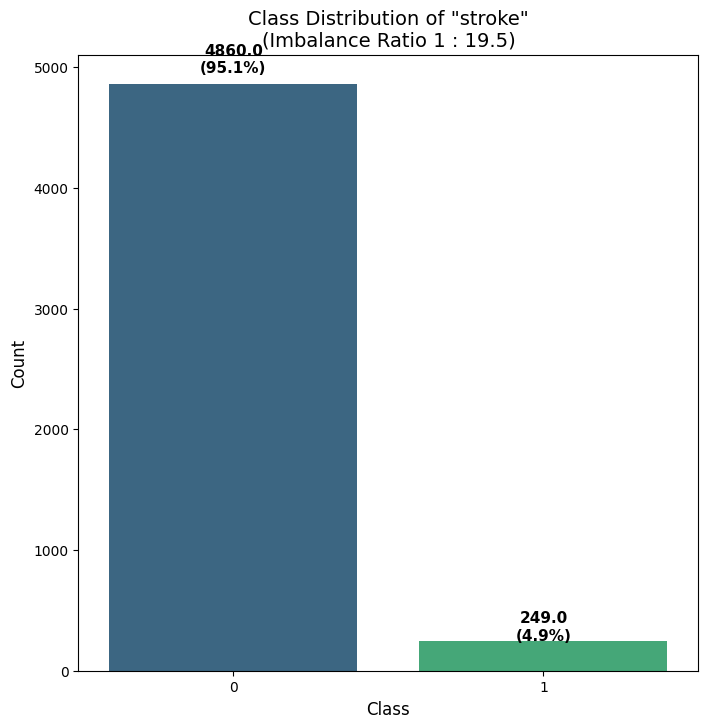

(19.518072289156628, 'SMOTE')

In [ ]:
detect_imbalance(df, 'stroke')

## 2.3 Correlation Matrix



========  Encoding for Correlation ========
-> Encoding applied. New shape: (5109, 16)
-> Features generated (One-Hot dropped first):
['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'stroke', 'gender_Male', 'ever_married_Yes', 'work_type_Never_worked', 'work_type_Private', 'work_type_Self-employed', 'work_type_children', 'Residence_type_Urban', 'smoking_status_formerly smoked', 'smoking_status_never smoked', 'smoking_status_smokes']

========  Correlation with Stroke ========
stroke                            1.000000
age                               0.245239
heart_disease                     0.134905
avg_glucose_level                 0.131991
hypertension                      0.127891
ever_married_Yes                  0.108299
smoking_status_formerly smoked    0.064683
work_type_Self-employed           0.062150
bmi                               0.042341
Residence_type_Urban              0.015415
work_type_Private                 0.011927
gender_Male             

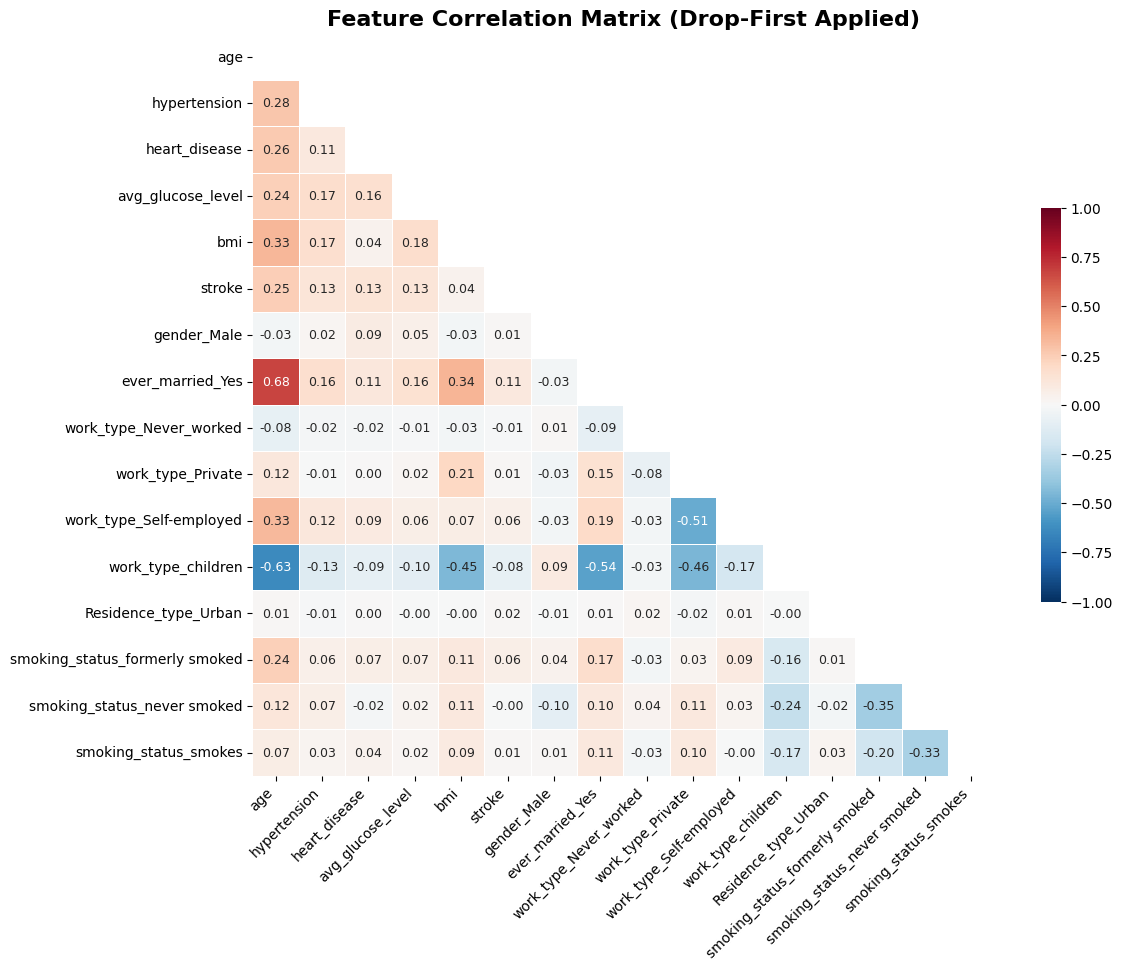

In [ ]:
# Drop ID column
if 'id' in df.columns:
    df_corr = df.drop(columns=['id'])
    print("-> 'id' column dropped successfully.")
else:
    df_corr = df.copy()

df_corr = df_corr[df_corr['gender'] != 'Other']

# One-Hot Encoding (With Drop First)
print("\n========  Encoding for Correlation ========")

categorical_cols = df_corr.select_dtypes(include=['object', 'category']).columns
df_encoded = pd.get_dummies(df_corr, columns=categorical_cols, drop_first=True)

print(f"-> Encoding applied. New shape: {df_encoded.shape}")
print("-> Features generated (One-Hot dropped first):")
print(df_encoded.columns.tolist())

# Correlation Matrix

corr_matrix = df_encoded.corr()
target_corr = corr_matrix['stroke'].sort_values(ascending=False)

print("\n========  Correlation with Stroke ========")
print(target_corr)
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix,
            mask=mask,
            cmap='RdBu_r',
            vmax=1,
            vmin=-1,
            center=0,
            square=True,
            linewidths=.5,
            cbar_kws={"shrink": .5},
            annot=True,
            fmt=".2f",
            annot_kws={"size": 9})

plt.title('Feature Correlation Matrix (Drop-First Applied)', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

##2.4 Preprocessing Pipeline

In [ ]:
numeric_features = ['age', 'avg_glucose_level', 'bmi']
categorical_features = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
binary_features = ['hypertension', 'heart_disease']

In [ ]:
# ==========================================
# Pipeline A: Logistic Regression (LR)
# Strategy: Impute -> One-Hot -> Scale
# ==========================================
preprocessor_lr = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numeric_features),

        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
        ]), categorical_features),

        ('bin', 'passthrough', binary_features)
    ],
    verbose_feature_names_out=False
)


In [ ]:
# =====================================================
# Pipeline B: Random Forest (RF)
# Strategy: Impute -> Ordinal Encode (No Scaling)
# =====================================================
preprocessor_rf = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='median'), numeric_features),

        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
        ]), categorical_features),

        ('bin', 'passthrough', binary_features)
    ],
    verbose_feature_names_out=False
)

In [ ]:
# =========================================
# 1. Define Features for MLP
# ==========================================
numeric_features_mlp = ['age', 'avg_glucose_level', 'age_x_glucose', 'age_x_heart']

# ==========================================
# 2. Define Core Functions
# ==========================================

# --- Function A: Feature Interactions ---
# Note: This function runs at the very beginning on the DataFrame, so string indexing works here.
def add_interactions(X):
    df = X.copy()
    # Fill NaN with 0 just for interaction calculation to avoid propagating NaNs
    df['age_x_glucose'] = df['age'] * df['avg_glucose_level']
    df['age_x_heart'] = df['age'] * df['heart_disease']
    return df

interaction_transformer = FunctionTransformer(add_interactions, validate=False)

# --- Function B: Medical BMI Binning  ---
def medical_bmi_binning(X):

    # 1. Flatten to 1D array for pd.cut
    bmi_values = X[:, 0]
    # 2. Binning using WHO standards
    # 0: Underweight (<18.5)
    # 1: Normal (18.5 - 24.9)
    # 2: Overweight (25.0 - 29.9)
    # 3: Obese (>30.0)
    bmi_cats = pd.cut(bmi_values,
                      bins=[-np.inf, 18.5, 25, 30, np.inf],
                      labels=[0, 1, 2, 3])

    # 3. Reshape back to 2D array (n_samples, 1) for sklearn compatibility
    return bmi_cats.to_numpy().reshape(-1, 1)

medical_binner = FunctionTransformer(medical_bmi_binning, validate=False)

# ==========================================
# 3. Build MLP Pipeline
# ==========================================

# Sub-pipeline for BMI
bmi_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('medical_bin', medical_binner),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Main Column Transformer
cols_trans_mlp = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numeric_features_mlp),

        ('bmi_med', bmi_pipeline, ['bmi']),

        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
        ]), categorical_features),

        ('bin', 'passthrough', binary_features)
    ],
    verbose_feature_names_out=False
)
preprocessor_mlp = Pipeline([
    ('interactions', interaction_transformer),
    ('cols_trans', cols_trans_mlp)
])

# Step 3: Model Training

## 3.1 Logistic Regression


In [ ]:
results = {}
pipe_lr = ImbPipeline([
    ('preprocessor', preprocessor_lr),
    ('smote', SMOTE(random_state=42)),
    ('clf', LogisticRegression(max_iter=2000))
])
pipe_lr.fit(X_train, y_train)
results['Logistic Regression'] = {
    'y_pred': pipe_lr.predict(X_test),
    'y_prob': pipe_lr.predict_proba(X_test)[:, 1]
}


## 3.2 Random Forest


In [ ]:
pipe_rf = ImbPipeline([
    ('preprocessor', preprocessor_rf),
    ('smote', SMOTE(random_state=42)),
    ('clf', RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42))
])
pipe_rf.fit(X_train, y_train)
results['Random Forest'] = {
    'y_pred': pipe_rf.predict(X_test),
    'y_prob': pipe_rf.predict_proba(X_test)[:, 1]
}


## 3.3 Deep Learning MLP


In [ ]:
# --- Model 3: Enhanced MLP  ---

# 3.1 Preprocessing & Resampling
X_train_mlp = preprocessor_mlp.fit_transform(X_train)
X_test_mlp = preprocessor_mlp.transform(X_test)

# Using SMOTE + Tomek to clean boundaries
smt = SMOTETomek(random_state=42)
X_train_res, y_train_res = smt.fit_resample(X_train_mlp, y_train)

# 3.2 Keras Model Definition (Simple 16-8-1)
model = keras.Sequential()
model.add(keras.Input(shape=(X_train_res.shape[1],)))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dropout(0.3))
model.add(layers.Dense(8, activation='relu'))
model.add(layers.Dropout(0.2))
model.add(layers.Dense(1, activation='sigmoid'))

# 3.3 Class Weights
weights = sklearn.utils.class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {0: weights[0], 1: weights[1] * 1.5} # Slightly increase weight for patients by 1.5 times

# 3.4 Compile & Train
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', keras.metrics.AUC(name='auc')])

history = model.fit(
    X_train_res, y_train_res,
    epochs=50, batch_size=32, validation_split=0.2, verbose=0,
    callbacks=[callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
    class_weight=class_weight_dict
)

# 3.5 Prediction
y_prob_mlp = model.predict(X_test_mlp).flatten()

# Using a default threshold of 0.5 for initial predictions
current_y_pred = (y_prob_mlp > 0.5).astype(int)
current_threshold = 0.5

results['Enhanced MLP'] = {'y_pred': current_y_pred, 'y_prob': y_prob_mlp, 'threshold': current_threshold}
print(f"\nFinal MLP AUC: {roc_auc_score(y_test, y_prob_mlp):.4f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

Final MLP AUC: 0.8421


#Step 4: Evaluation & Visualization


## 4.1 ROC Curve Comparison


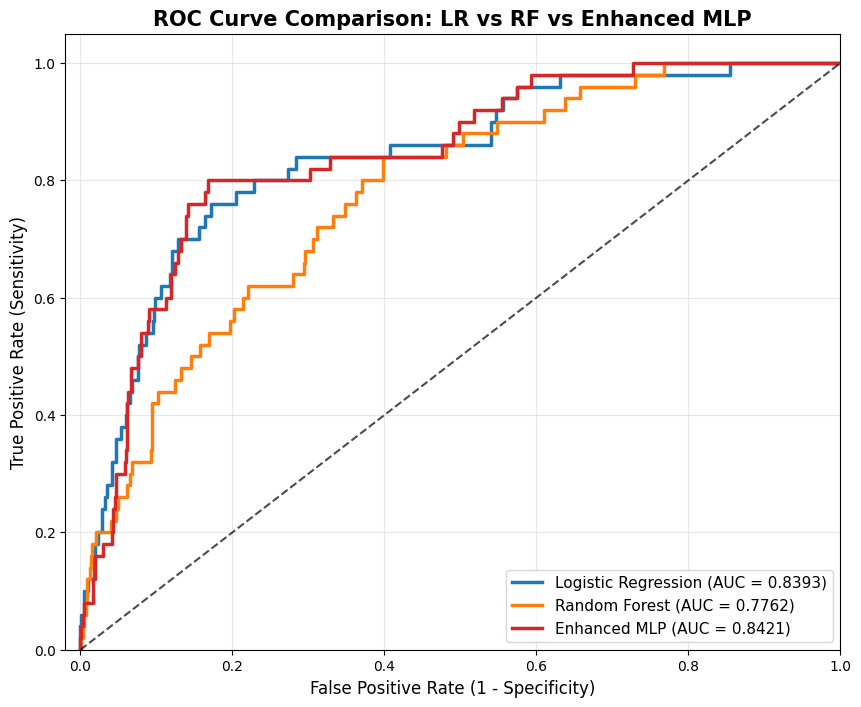

In [ ]:
plt.figure(figsize=(10, 8))
colors = ['#1f77b4', '#ff7f0e', '#d62728'] # Blue, Orange, Red

for (name, res), color in zip(results.items(), colors):
    auc = roc_auc_score(y_test, res['y_prob'])
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])

    plt.plot(fpr, tpr, color=color, lw=2.5, label=f'{name} (AUC = {auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.7)
plt.xlim([-0.02, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title('ROC Curve Comparison: LR vs RF vs Enhanced MLP', fontsize=15, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()


## 4.2 Confusion Matrices


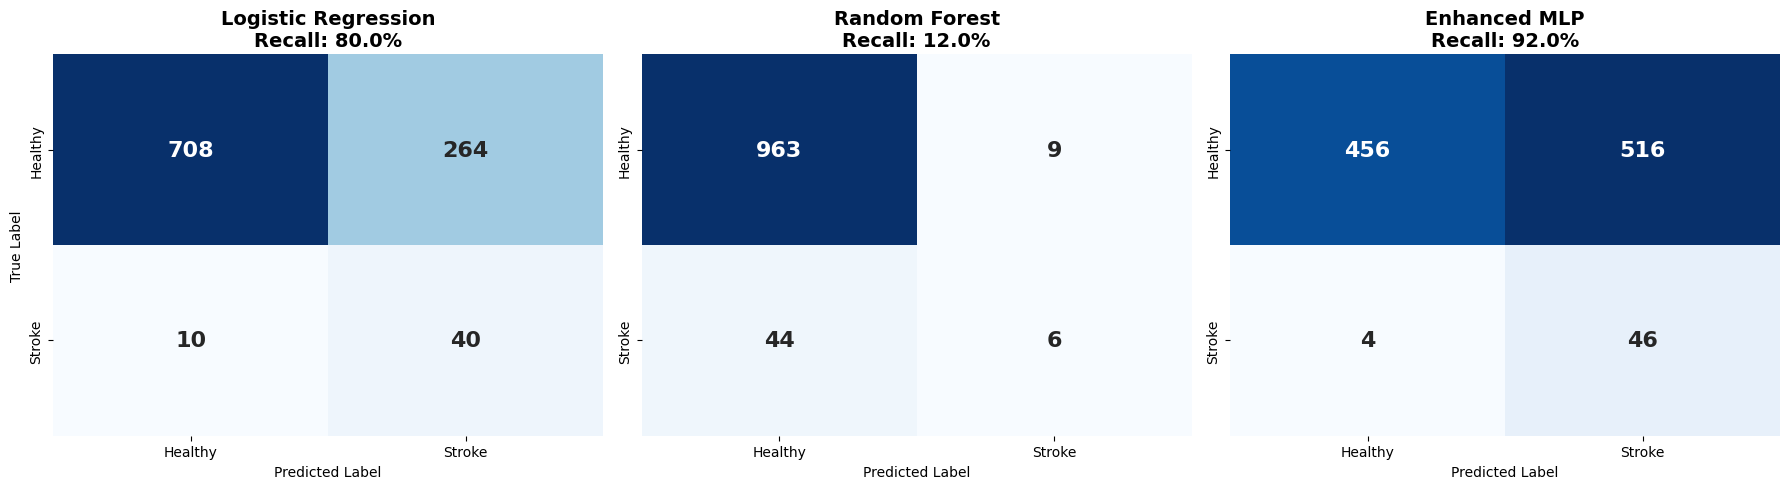

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    recall = recall_score(y_test, res['y_pred'])

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                annot_kws={"size": 16, "weight": "bold"}, cbar=False)

    ax.set_title(f"{name}\nRecall: {recall:.1%}", fontsize=14, fontweight='bold')
    ax.set_xlabel('Predicted Label')
    if name == 'Logistic Regression': ax.set_ylabel('True Label')
    ax.set_xticklabels(['Healthy', 'Stroke'])
    ax.set_yticklabels(['Healthy', 'Stroke'])

plt.tight_layout()
plt.show()


## 4.3 Final Metrics Table


In [ ]:
metrics_list = []
for name, res in results.items():
    metrics_list.append({
        'Model': name,
        'AUC': roc_auc_score(y_test, res['y_prob']),
        'Accuracy': accuracy_score(y_test, res['y_pred']),
        'Recall (Sensitivity)': recall_score(y_test, res['y_pred']),
        'Precision': precision_score(y_test, res['y_pred']),
        'F1 Score': f1_score(y_test, res['y_pred'])
    })

df_metrics = pd.DataFrame(metrics_list).set_index('Model').sort_values('AUC', ascending=False)
print("\n======== Final Performance Leaderboard ========")
display(df_metrics)
print("\n======== Markdown Style Table ========")
print(df_metrics.to_markdown(floatfmt=".4f", numalign="center", stralign="center"))


======== Final Performance Leaderboard ========


,AUC,Accuracy,Recall (Sensitivity),Precision,F1 Score
Model,,,,,
Enhanced MLP,0.842058,0.491194,0.92,0.081851,0.150327
Logistic Regression,0.839342,0.731898,0.80,0.131579,0.225989
Random Forest,0.776152,0.948141,0.12,0.400000,0.184615



======== Markdown Style Table ========
|        Model        |  AUC   |  Accuracy  |  Recall (Sensitivity)  |  Precision  |  F1 Score  |
|:-------------------:|:------:|:----------:|:----------------------:|:-----------:|:----------:|
|    Enhanced MLP     | 0.8421 |   0.4912   |         0.9200         |   0.0819    |   0.1503   |
| Logistic Regression | 0.8393 |   0.7319   |         0.8000         |   0.1316    |   0.2260   |
|    Random Forest    | 0.7762 |   0.9481   |         0.1200         |   0.4000    |   0.1846   |
